# Combining all results (SAMSEG)

This notebook mirrors `7-combine_results.ipynb` but replaces the second method with SAMSEG outputs produced in notebook 7b.

In [1]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import SimpleITK as sitk
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score
from pathlib import Path
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests
import utils as ut

colors_seg = ['#FFC107', '#1E88E5']  # BOB vs SAMSEG

## Loading and merging data

In [2]:
# Paths (relative to data_pipeline)
P_BASE = Path('outputs')
P_SAM = P_BASE / 'samseg'

# FD per-structure: BOB vs SAMSEG
# from 7: 'outputs/BOB_fd_results.csv' and 'outputs/BOB_fd_results_freesurfer-seg.csv'
df_fd_BOB = pd.read_csv(P_BASE / 'BOB_fd_results.csv')
df_fd_samseg = pd.read_csv(P_SAM / 'BOB_fd_results_samseg.csv')

# Segmentation metrics and volumes
# from 7: 'outputs/segmentation_metrics.csv' + 'outputs/whole_brain_csf_metrics.csv'
#        'outputs/segmentation_volumes.csv'
df_seg_metrics = pd.read_csv(P_BASE / 'segmentation_metrics.csv')
df_seg_metrics_wb = pd.read_csv(P_BASE / 'whole_brain_csf_metrics.csv')
df_seg_metrics_all = pd.concat([df_seg_metrics, df_seg_metrics_wb], ignore_index=True, sort=False)

df_seg_volumnes = pd.read_csv(P_BASE / 'segmentation_volumes.csv')

# SAMSEG counterparts
# metrics + volumes computed in 7b and stored under outputs/samseg/
df_seg_metrics_samseg = pd.read_csv(P_SAM / 'segmentation_metrics_samseg.csv')
df_seg_metrics_wb2   = pd.read_csv(P_SAM / 'whole_brain_csf_metrics_samseg.csv')
df_seg_metrics_all2  = pd.concat([df_seg_metrics_samseg, df_seg_metrics_wb2], ignore_index=True, sort=False)

df_seg_volumnes_samseg = pd.read_csv(P_SAM / 'segmentation_volumes_samseg.csv')

# Whole brain minus CSF FD
# from 7: outputs/fd_wb_minus_csf.csv
df_fd_wb = pd.read_csv(P_BASE / 'fd_wb_minus_csf.csv')
df_fd_wb_samseg = pd.read_csv(P_SAM / 'fd_wb_minus_csf_samseg.csv')

# Align structures present in both FD tables
common_names = pd.Series(list(set(df_fd_BOB['name'].unique()) & set(df_fd_samseg['name'].unique())))
df_fd_BOB_common = df_fd_BOB[df_fd_BOB['name'].isin(common_names)].rename(columns={'fd': 'fd_BOB'})
df_fd_samseg_common = df_fd_samseg[df_fd_samseg['name'].isin(common_names)].rename(columns={'fd': 'fd_Samseg'})

# Merge per structure
df_fd_merged = pd.merge(
    df_fd_BOB_common[['participant_id', 'session_id', 'name', 'fd_BOB','age','sex']],
    df_fd_samseg_common[['participant_id', 'session_id', 'name', 'fd_Samseg']],
    on=['participant_id', 'session_id', 'name'],
    how='inner'
)

df_fd_merged.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_Samseg
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8645
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.5723
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.3986
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,2.2229
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.7720


In [3]:
# Enrich WB- CSF table with age/sex from merged FD
meta = df_fd_merged[["participant_id","session_id","age","sex"]].drop_duplicates()

# Use SAMSEG WB−CSF (SAMSEG counterpart of 7-)
df_fd_wb_samseg_enriched = df_fd_wb_samseg.merge(meta, on=["participant_id","session_id"], how="left")

# For consistency, drop helper columns if present
for df in (df_fd_wb_samseg_enriched,):
    for col in ('label','min_box_size','max_box_size'):
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

# Final FD table: per-structure + WB−CSF (SAMSEG)
df_fd_all = pd.concat([df_fd_merged, df_fd_wb_samseg_enriched], ignore_index=True, sort=False)
df_fd_all.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_Samseg
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8645
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.5723
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.3986
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,2.2229
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.7720


In [4]:
# Standardize names: SAMSEG volumes/metrics have .nii suffix
for df in (df_seg_volumnes_samseg, df_seg_metrics_all2):
    if 'name' in df.columns:
        df['name'] = df['name'].astype(str).str.replace(r'\.nii$', '', regex=True)

# Pivot volumes and metrics (BOB vs SAMSEG)
df_seg_volumnes_wide = df_seg_volumnes_samseg.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()

df_seg_metrics_wide = df_seg_metrics_all2.pivot_table(
    index=['participant_id', 'session_id', 'name'],
    columns='metric',
    values='value'
).reset_index()

# Join with FD
# Note: volume_Samseg is used instead of volume_SynthSeg in SAMSEG variant
df_fd_volume = pd.merge(
    df_fd_all,
    df_seg_volumnes_wide,
    on=['participant_id', 'session_id','name'],
    how='inner'
)

df_fd_volume_metrics = pd.merge(
    df_fd_volume,
    df_seg_metrics_wide,
    on=['participant_id', 'session_id','name'],
    how='inner'
)

df_fd_volume_metrics.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_Samseg,volume_BOB,volume_Samseg,volume_diff,volume_diff_abs,volume_norm_percent_diff,volume_ratio,Dice,HD95,Hausdorff,IoU,MI,NMI
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8645,713007.0,2454078.0,-1741071.0,1741071.0,109.947854,0.290540,0.450258,43.462627,54.479354,0.290538,1.174924e-01,0.243952
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.5723,147515.0,271346.0,-123831.0,123831.0,59.127491,0.543642,0.566598,9.486833,65.650590,0.395282,4.805185e-02,0.369817
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.3986,146600.0,218110.0,-71510.0,71510.0,39.214719,0.672138,0.158202,13.928389,41.581246,0.085896,4.621208e-03,0.039386
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,2.2229,4487.0,13639.0,-9152.0,9152.0,100.982015,0.328983,0.031667,13.564660,21.023796,0.016088,1.030476e-04,0.010880
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.7720,351.0,1152.0,-801.0,801.0,106.586826,0.304688,0.000000,20.609447,40.174619,0.000000,7.755439e-09,0.000007


In [5]:
# Compute FD diffs (BOB - SAMSEG)
df_fd_all['fd_diff'] = df_fd_all['fd_BOB'] - df_fd_all.get('fd_Samseg', np.nan)
df_fd_all['fd_diff_abs'] = df_fd_all['fd_diff'].abs()

# Merge diffs into combined table (already present in volumes CSV, keep for safety)
for col in ['volume_BOB','volume_Samseg','volume_diff','volume_diff_abs','volume_norm_percent_diff']:
    if col not in df_fd_volume_metrics.columns and col in df_seg_volumnes_wide.columns:
        df_fd_volume_metrics[col] = df_seg_volumnes_wide.set_index(['participant_id','session_id','name'])[col].reindex(
            df_fd_volume_metrics.set_index(['participant_id','session_id','name']).index
        ).values

# Also bring FD difference columns into df_fd_volume_metrics for downstream plots
idx_cols = ['participant_id','session_id','name']
fd_diffs = (
    df_fd_all[idx_cols + ['fd_diff','fd_diff_abs']]
    .drop_duplicates(subset=idx_cols)
)
df_fd_volume_metrics = df_fd_volume_metrics.merge(fd_diffs, on=idx_cols, how='left')

# Create base_name and side to mirror 7-
df_fd_volume_metrics['base_name'] = df_fd_volume_metrics['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_fd_volume_metrics['side'] = df_fd_volume_metrics['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none')

# Convert mm3 to mL
volume_cols = ['volume_BOB','volume_Samseg','volume_diff','volume_diff_abs']
for c in volume_cols:
    if c in df_fd_volume_metrics.columns:
        df_fd_volume_metrics[c] = df_fd_volume_metrics[c] / 1000.0

df_fd_volume_metrics.head()

,participant_id,session_id,name,fd_BOB,age,sex,fd_Samseg,volume_BOB,volume_Samseg,volume_diff,...,Dice,HD95,Hausdorff,IoU,MI,NMI,fd_diff,fd_diff_abs,base_name,side
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8645,713.007,2454.078,-1741.071,...,0.450258,43.462627,54.479354,0.290538,1.174924e-01,0.243952,-0.1047,0.1047,whole_brain,none
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.5723,147.515,271.346,-123.831,...,0.566598,9.486833,65.650590,0.395282,4.805185e-02,0.369817,-0.1019,0.1019,Cerebral-White-Matter,Left
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.3986,146.600,218.110,-71.510,...,0.158202,13.928389,41.581246,0.085896,4.621208e-03,0.039386,0.0489,0.0489,Cerebral-Cortex,Left
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,2.2229,4.487,13.639,-9.152,...,0.031667,13.564660,21.023796,0.016088,1.030476e-04,0.010880,-0.7177,0.7177,Lateral-Ventricle,Left
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.7720,0.351,1.152,-0.801,...,0.000000,20.609447,40.174619,0.000000,7.755439e-09,0.000007,-0.3859,0.3859,Inf-Lat-Vent,Left


In [6]:
def plot_structure_metric_correlations(
    df,
    selected_name,
    x_col,
    metrics=("Dice", "IoU", "NMI", "HD95"),
    use_fdr=True,
    alpha=0.05,
    exclude=("CSF",),
    sort_by="Dice"
):
    structures = [s for s in df[selected_name].unique() if s not in exclude]
    corr_df = pd.DataFrame(index=structures, columns=metrics, dtype=float)
    pval_df = pd.DataFrame(index=structures, columns=metrics, dtype=float)
    for struct in structures:
        sub = df[df[selected_name] == struct]
        for metric in metrics:
            valid = sub[[x_col, metric]].dropna()
            if len(valid) > 1:
                r, p = pearsonr(valid[x_col], valid[metric])
            else:
                r, p = np.nan, np.nan
            corr_df.at[struct, metric] = r
            pval_df.at[struct, metric] = p
    if use_fdr:
        flat_p = pval_df.values.flatten()
        valid_mask = ~np.isnan(flat_p)
        adj_p = np.full_like(flat_p, np.nan, dtype=float)
        if valid_mask.any():
            _, p_corr, _, _ = multipletests(flat_p[valid_mask], alpha=alpha, method="fdr_bh")
            adj_p[valid_mask] = p_corr
        adj_p_df = pd.DataFrame(adj_p.reshape(pval_df.shape), index=pval_df.index, columns=pval_df.columns)
    else:
        adj_p_df = pval_df.copy()

    def stars(p):
        if pd.isna(p): return ""
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""

    annot = corr_df.copy().astype(str)
    for i in annot.index:
        for j in annot.columns:
            r = corr_df.loc[i, j]
            p = adj_p_df.loc[i, j]
            annot.loc[i, j] = "" if pd.isna(r) else f"{r:.2f}{stars(p)}"

    corr_df = corr_df.sort_values(by=sort_by, ascending=True)
    annot = annot.reindex(index=corr_df.index, columns=corr_df.columns)

    fig_h = len(corr_df) * 0.35 + 2
    plt.figure(figsize=(8, fig_h))
    ax = sns.heatmap(
        corr_df.astype(float),
        annot=annot,
        fmt="",
        cmap="vlag",
        center=0,
        cbar_kws={"label": "Pearson r"},
        linewidths=0.5,
        annot_kws={"fontsize": 9}
    )
    plt.title(f"Correlation: {x_col} vs Metrics per Structure\n(SAMSEG variant)")
    plt.xlabel("Metric")
    plt.ylabel("Structure")
    plt.tight_layout()
    plt.show()
    return corr_df, adj_p_df

## General settings

In [7]:
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name for name in df_fd_volume_metrics[selected_name].unique() if name != 'CSF']
base_list.sort()
base_list[:5]

['3rd-Ventricle', '4th-Ventricle', 'Accumbens-area', 'Amygdala', 'Brain-Stem']

### Quality metrics over age

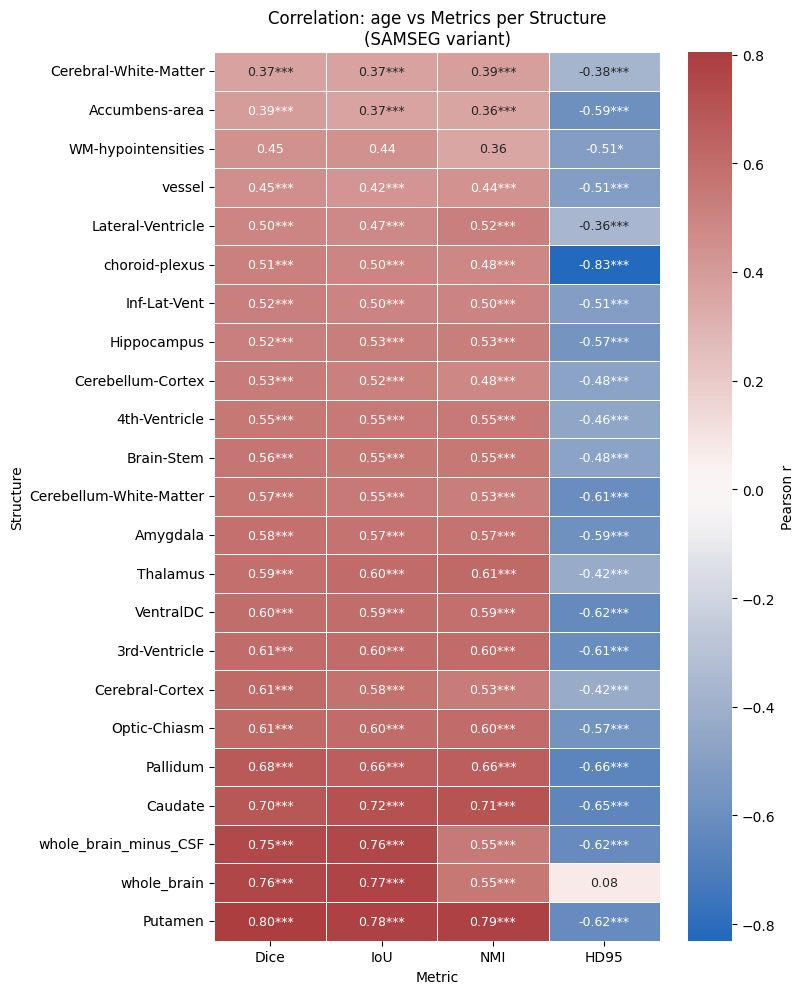

In [8]:
corr_age, pvals_age = plot_structure_metric_correlations(
    df_fd_volume_metrics,
    selected_name=selected_name,
    x_col="age",
    use_fdr=True,
    alpha=0.05
)

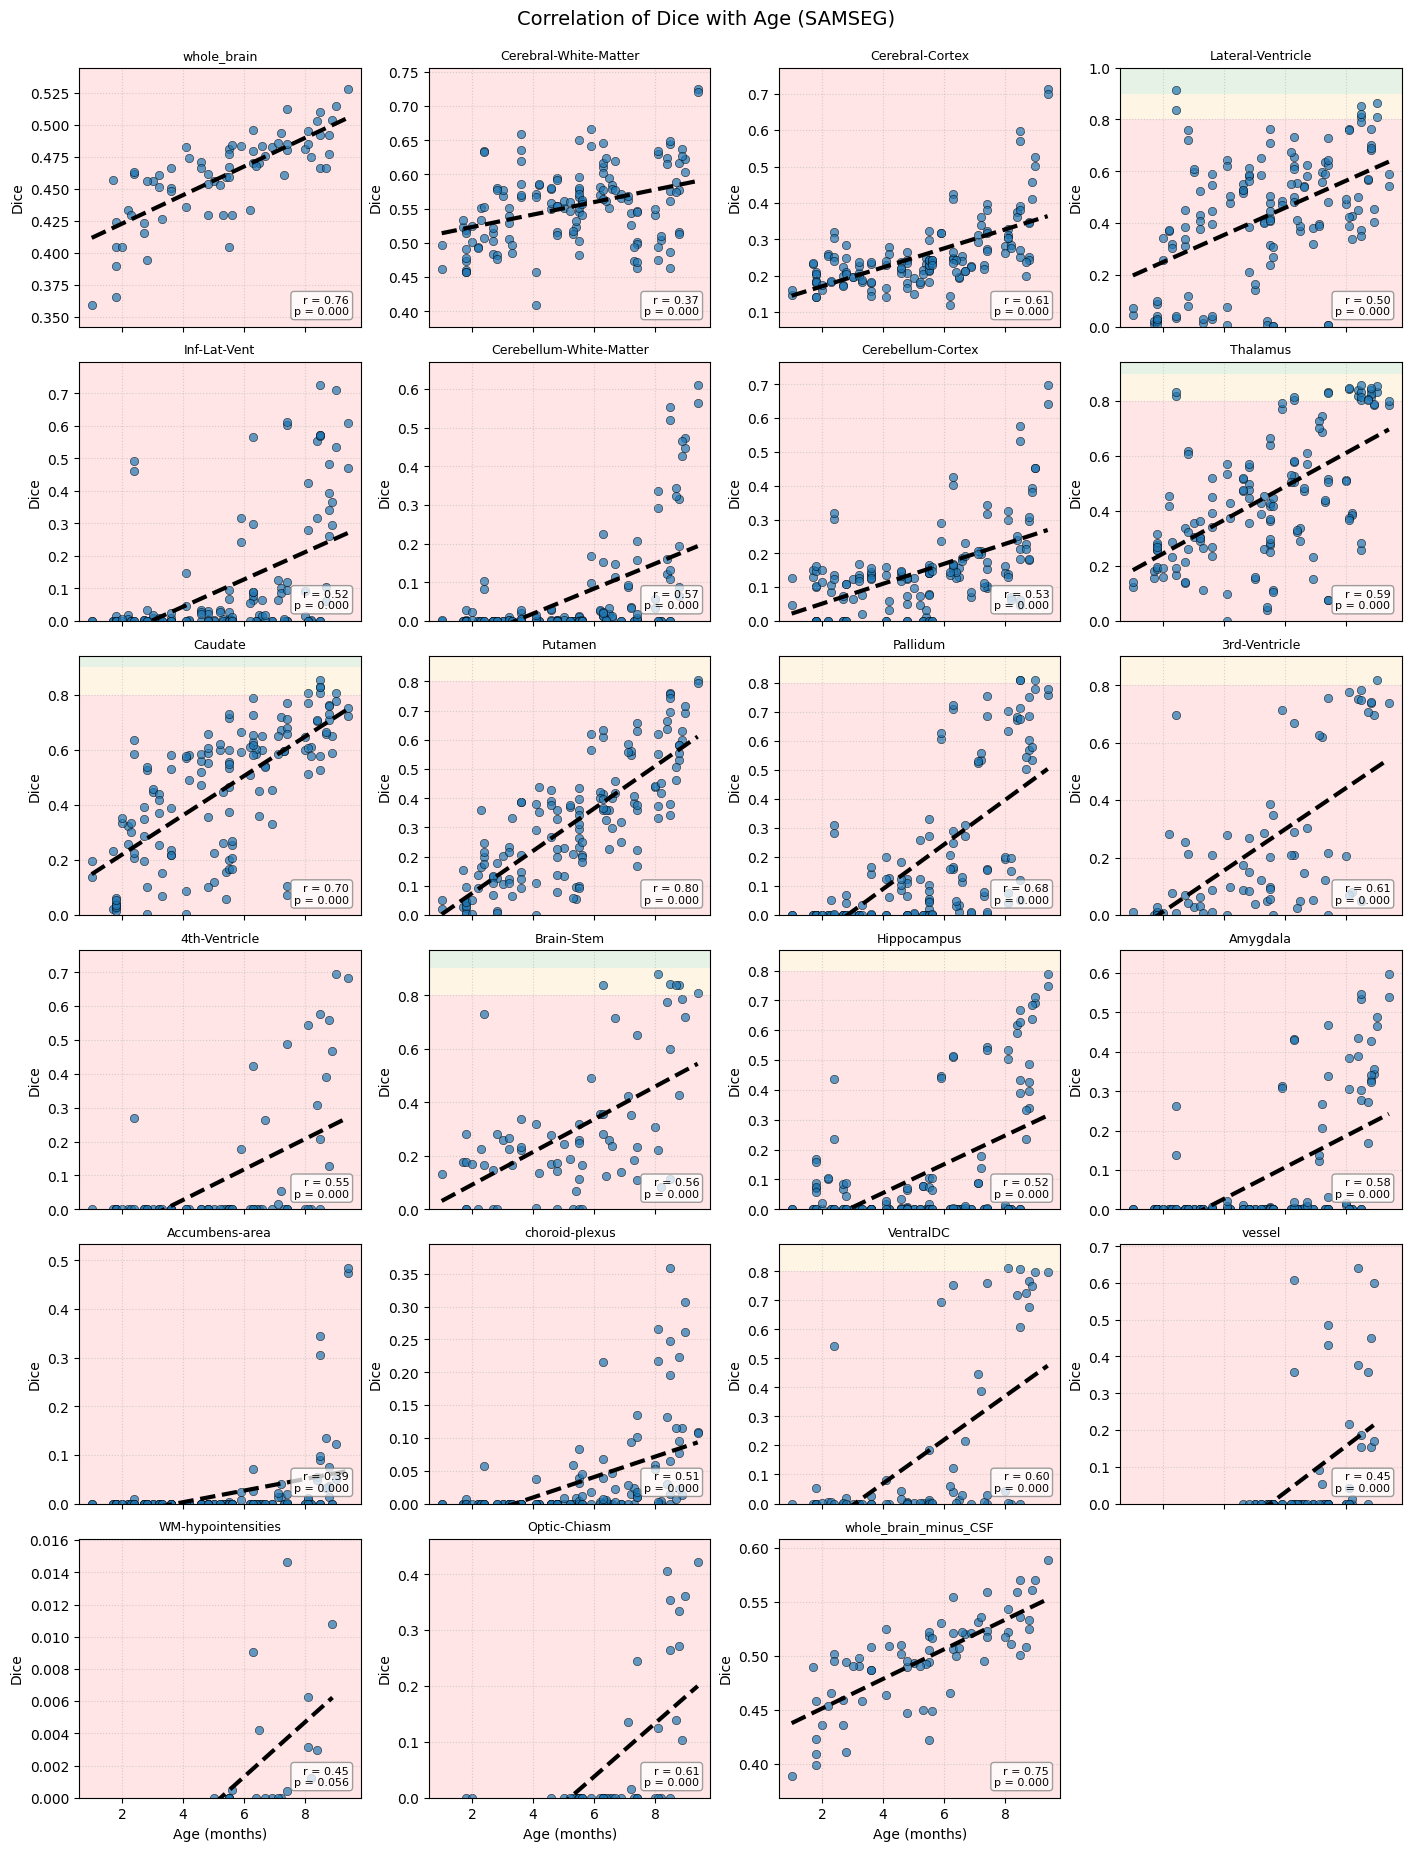

In [9]:
metric    = "Dice"

structures = [s for s in df_fd_volume_metrics[selected_name].unique() if s != "CSF"]

ncols = 4
nrows = int(np.ceil(len(structures) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*3.0), constrained_layout=True, sharex=True, sharey=False)
axes = axes.flatten()

for ax, struct in zip(axes, structures):
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == struct].dropna(subset=['age', metric])

    if sub.empty:
        ax.axis("off")
        continue

    x = sub['age'].values
    y = sub[metric].values

    ax.axhspan(0, 0.8, facecolor="red", alpha=0.1)
    ax.axhspan(0.8, 0.9, facecolor="orange", alpha=0.1)
    ax.axhspan(0.9, 1.0, facecolor="green", alpha=0.1)

    sns.scatterplot(x=x, y=y, ax=ax, edgecolor="k", alpha=0.7)

    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, linestyle="--", color="#000000", linewidth=3)
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    ax.text(
        0.96, 0.04,
        f"r = {r:.2f}\np = {p:.3f}",
        transform=ax.transAxes, va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.75),
        fontsize=8
    )

    ax.set_title(struct, fontsize=9)
    ax.set_ylabel(metric)
    ax.set_xlabel('Age (months)')
    ax.grid(True, linestyle=":", alpha=0.5)

    if len(y) > 0:
        y_min, y_max = np.min(y), np.max(y)
        margin = 0.1 * (y_max - y_min if y_max > y_min else 1)
        ax.set_ylim(max(0, y_min - margin), min(1.0, y_max + margin))

for ax in axes[len(structures):]:
    ax.axis("off")

fig.suptitle(f"Correlation of {metric} with Age (SAMSEG)", fontsize=14, y=1.02)
plt.show()

## Volume

### BOB vs. SAMSEG

In [10]:
stats_list = []

for label in base_list:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == label]
    if sub.empty:
        continue
    bob = sub['volume_BOB']
    sam = sub['volume_Samseg']
    diff = bob - sam
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(bob, sam)
    d_val = ut.cohen_d_paired(bob, sam)
    stats_list.append({
        'name': label,
        'Volume (BOB)': f"{bob.mean():.2f} ± {bob.std(ddof=1):.2f}",
        'Volume (SAMSEG)': f"{sam.mean():.2f} ± {sam.std(ddof=1):.2f}",
        'Volume (diff)': f"{mean_diff:.2f} ± {sd_diff:.2f}",
        'n': len(diff),
        'p-val': f"{p_val:.3f}",
        'd': f"{d_val:.2f}"
    })

df_stats_vol = pd.DataFrame(stats_list)
df_stats_vol

,name,Volume (BOB),Volume (SAMSEG),Volume (diff),n,p-val,d
0,3rd-Ventricle,0.64 ± 0.15,1.48 ± 0.65,-0.84 ± 0.63,71,0.000,-1.33
1,4th-Ventricle,0.76 ± 0.17,2.06 ± 0.92,-1.30 ± 0.87,71,0.000,-1.49
2,Accumbens-area,0.32 ± 0.10,0.43 ± 0.10,-0.11 ± 0.12,142,0.000,-0.95
3,Amygdala,0.79 ± 0.18,1.58 ± 0.32,-0.80 ± 0.31,142,0.000,-2.61
4,Brain-Stem,9.81 ± 1.38,15.41 ± 3.38,-5.59 ± 3.13,71,0.000,-1.79
5,Caudate,2.67 ± 0.62,2.36 ± 0.40,0.31 ± 0.54,142,0.000,0.57
6,Cerebellum-Cortex,28.26 ± 7.46,46.04 ± 10.22,-17.78 ± 8.15,142,0.000,-2.18
7,Cerebellum-White-Matter,5.96 ± 2.37,12.35 ± 2.29,-6.39 ± 2.65,142,0.000,-2.41
8,Cerebral-Cortex,157.10 ± 37.96,192.86 ± 21.86,-35.76 ± 26.72,142,0.000,-1.34
9,Cerebral-White-Matter,129.06 ± 21.48,243.12 ± 30.66,-114.06 ± 24.38,142,0.000,-4.68


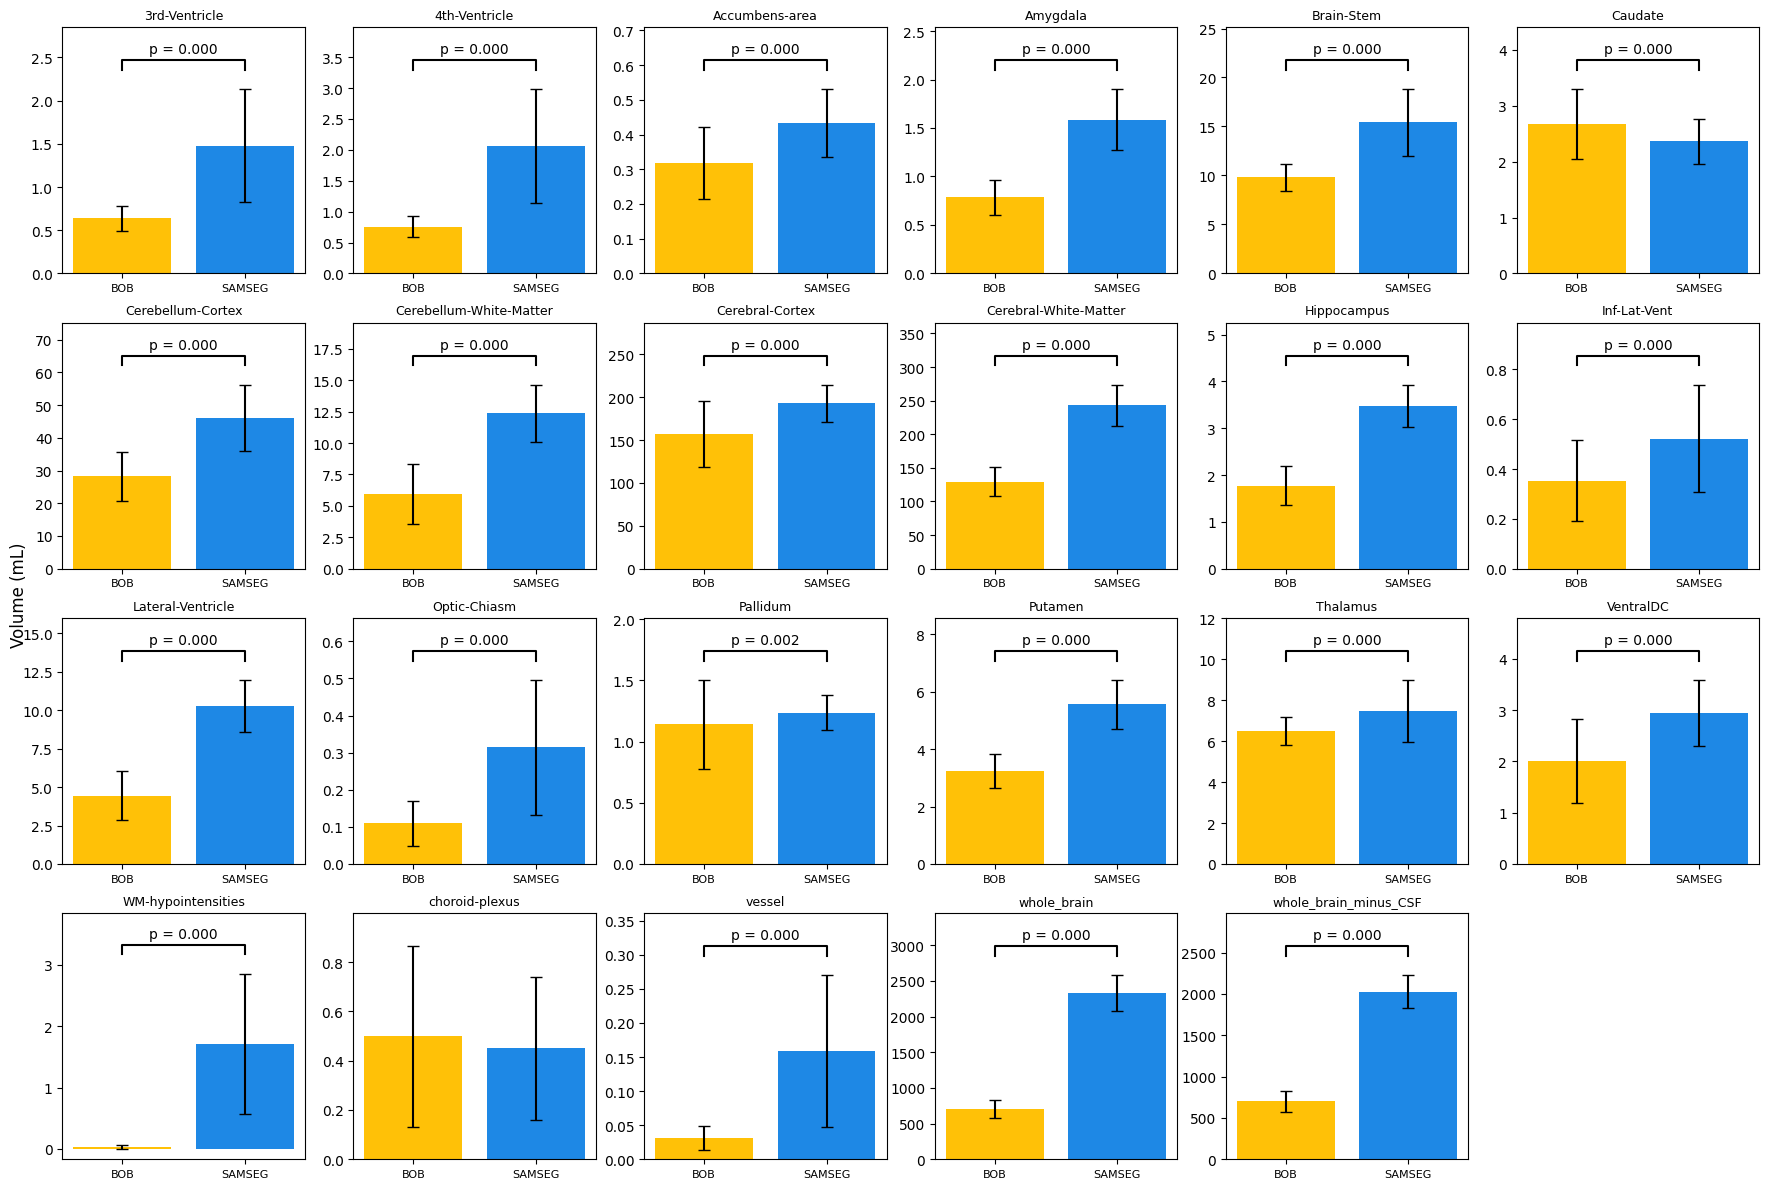

In [11]:
agg = df_fd_volume_metrics.groupby(selected_name)[['volume_BOB', 'volume_Samseg']].agg(['mean', 'std'])

n_pairs = len(base_list)
ncols = 6
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharey=False)
axes = axes.flatten()

for ax, label in zip(axes, base_list):
    if label not in agg.index:
        ax.axis('off')
        continue
    means = agg.loc[label][('volume_BOB', 'mean')], agg.loc[label][('volume_Samseg', 'mean')]
    stds  = agg.loc[label][('volume_BOB', 'std')],  agg.loc[label][('volume_Samseg', 'std')]

    x = np.arange(2)
    ax.bar(x, means, yerr=stds, capsize=4, color=colors_seg)
    ax.set_xticks(x)
    ax.set_xticklabels(['BOB', 'SAMSEG'], fontsize=8)
    ax.set_title(label, fontsize=9)

    p = float(df_stats_vol[df_stats_vol['name'] == label]['p-val'].iloc[0]) if label in set(df_stats_vol['name']) else np.nan
    if not np.isnan(p) and p < 0.05:
        ut.barplot_annotate_brackets(0, 1,
            f'p = {p:.3f}', x, means, yerr=stds, dh=0.1, ax=ax
        )
    ax.set_ylim([min(ax.get_ylim()), max(ax.get_ylim()) * 1.1])

for ax in axes[n_pairs:]:
    ax.axis('off')

fig.supylabel("Volume (mL)", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

In [12]:
# Bonferroni correction for paired tests
n_tests = len(df_stats_vol)
alpha_corr = 0.05 / n_tests if n_tests else np.nan

df_stats_vol['p_nominal'] = df_stats_vol['p-val'].astype(float)
df_stats_vol['sign_corr'] = df_stats_vol['p_nominal'] < alpha_corr if not np.isnan(alpha_corr) else False

print(f"Bonferroni α = {alpha_corr:.4f}" if not np.isnan(alpha_corr) else "No tests")
df_stats_vol.loc[df_stats_vol['sign_corr'], ['name', 'Volume (BOB)', 'Volume (SAMSEG)', 'Volume (diff)','n', 'p-val', 'd']]

Bonferroni α = 0.0022


,name,Volume (BOB),Volume (SAMSEG),Volume (diff),n,p-val,d
0,3rd-Ventricle,0.64 ± 0.15,1.48 ± 0.65,-0.84 ± 0.63,71,0.000,-1.33
1,4th-Ventricle,0.76 ± 0.17,2.06 ± 0.92,-1.30 ± 0.87,71,0.000,-1.49
2,Accumbens-area,0.32 ± 0.10,0.43 ± 0.10,-0.11 ± 0.12,142,0.000,-0.95
3,Amygdala,0.79 ± 0.18,1.58 ± 0.32,-0.80 ± 0.31,142,0.000,-2.61
4,Brain-Stem,9.81 ± 1.38,15.41 ± 3.38,-5.59 ± 3.13,71,0.000,-1.79
5,Caudate,2.67 ± 0.62,2.36 ± 0.40,0.31 ± 0.54,142,0.000,0.57
6,Cerebellum-Cortex,28.26 ± 7.46,46.04 ± 10.22,-17.78 ± 8.15,142,0.000,-2.18
7,Cerebellum-White-Matter,5.96 ± 2.37,12.35 ± 2.29,-6.39 ± 2.65,142,0.000,-2.41
8,Cerebral-Cortex,157.10 ± 37.96,192.86 ± 21.86,-35.76 ± 26.72,142,0.000,-1.34
9,Cerebral-White-Matter,129.06 ± 21.48,243.12 ± 30.66,-114.06 ± 24.38,142,0.000,-4.68


### BOB/SAMSEG over age

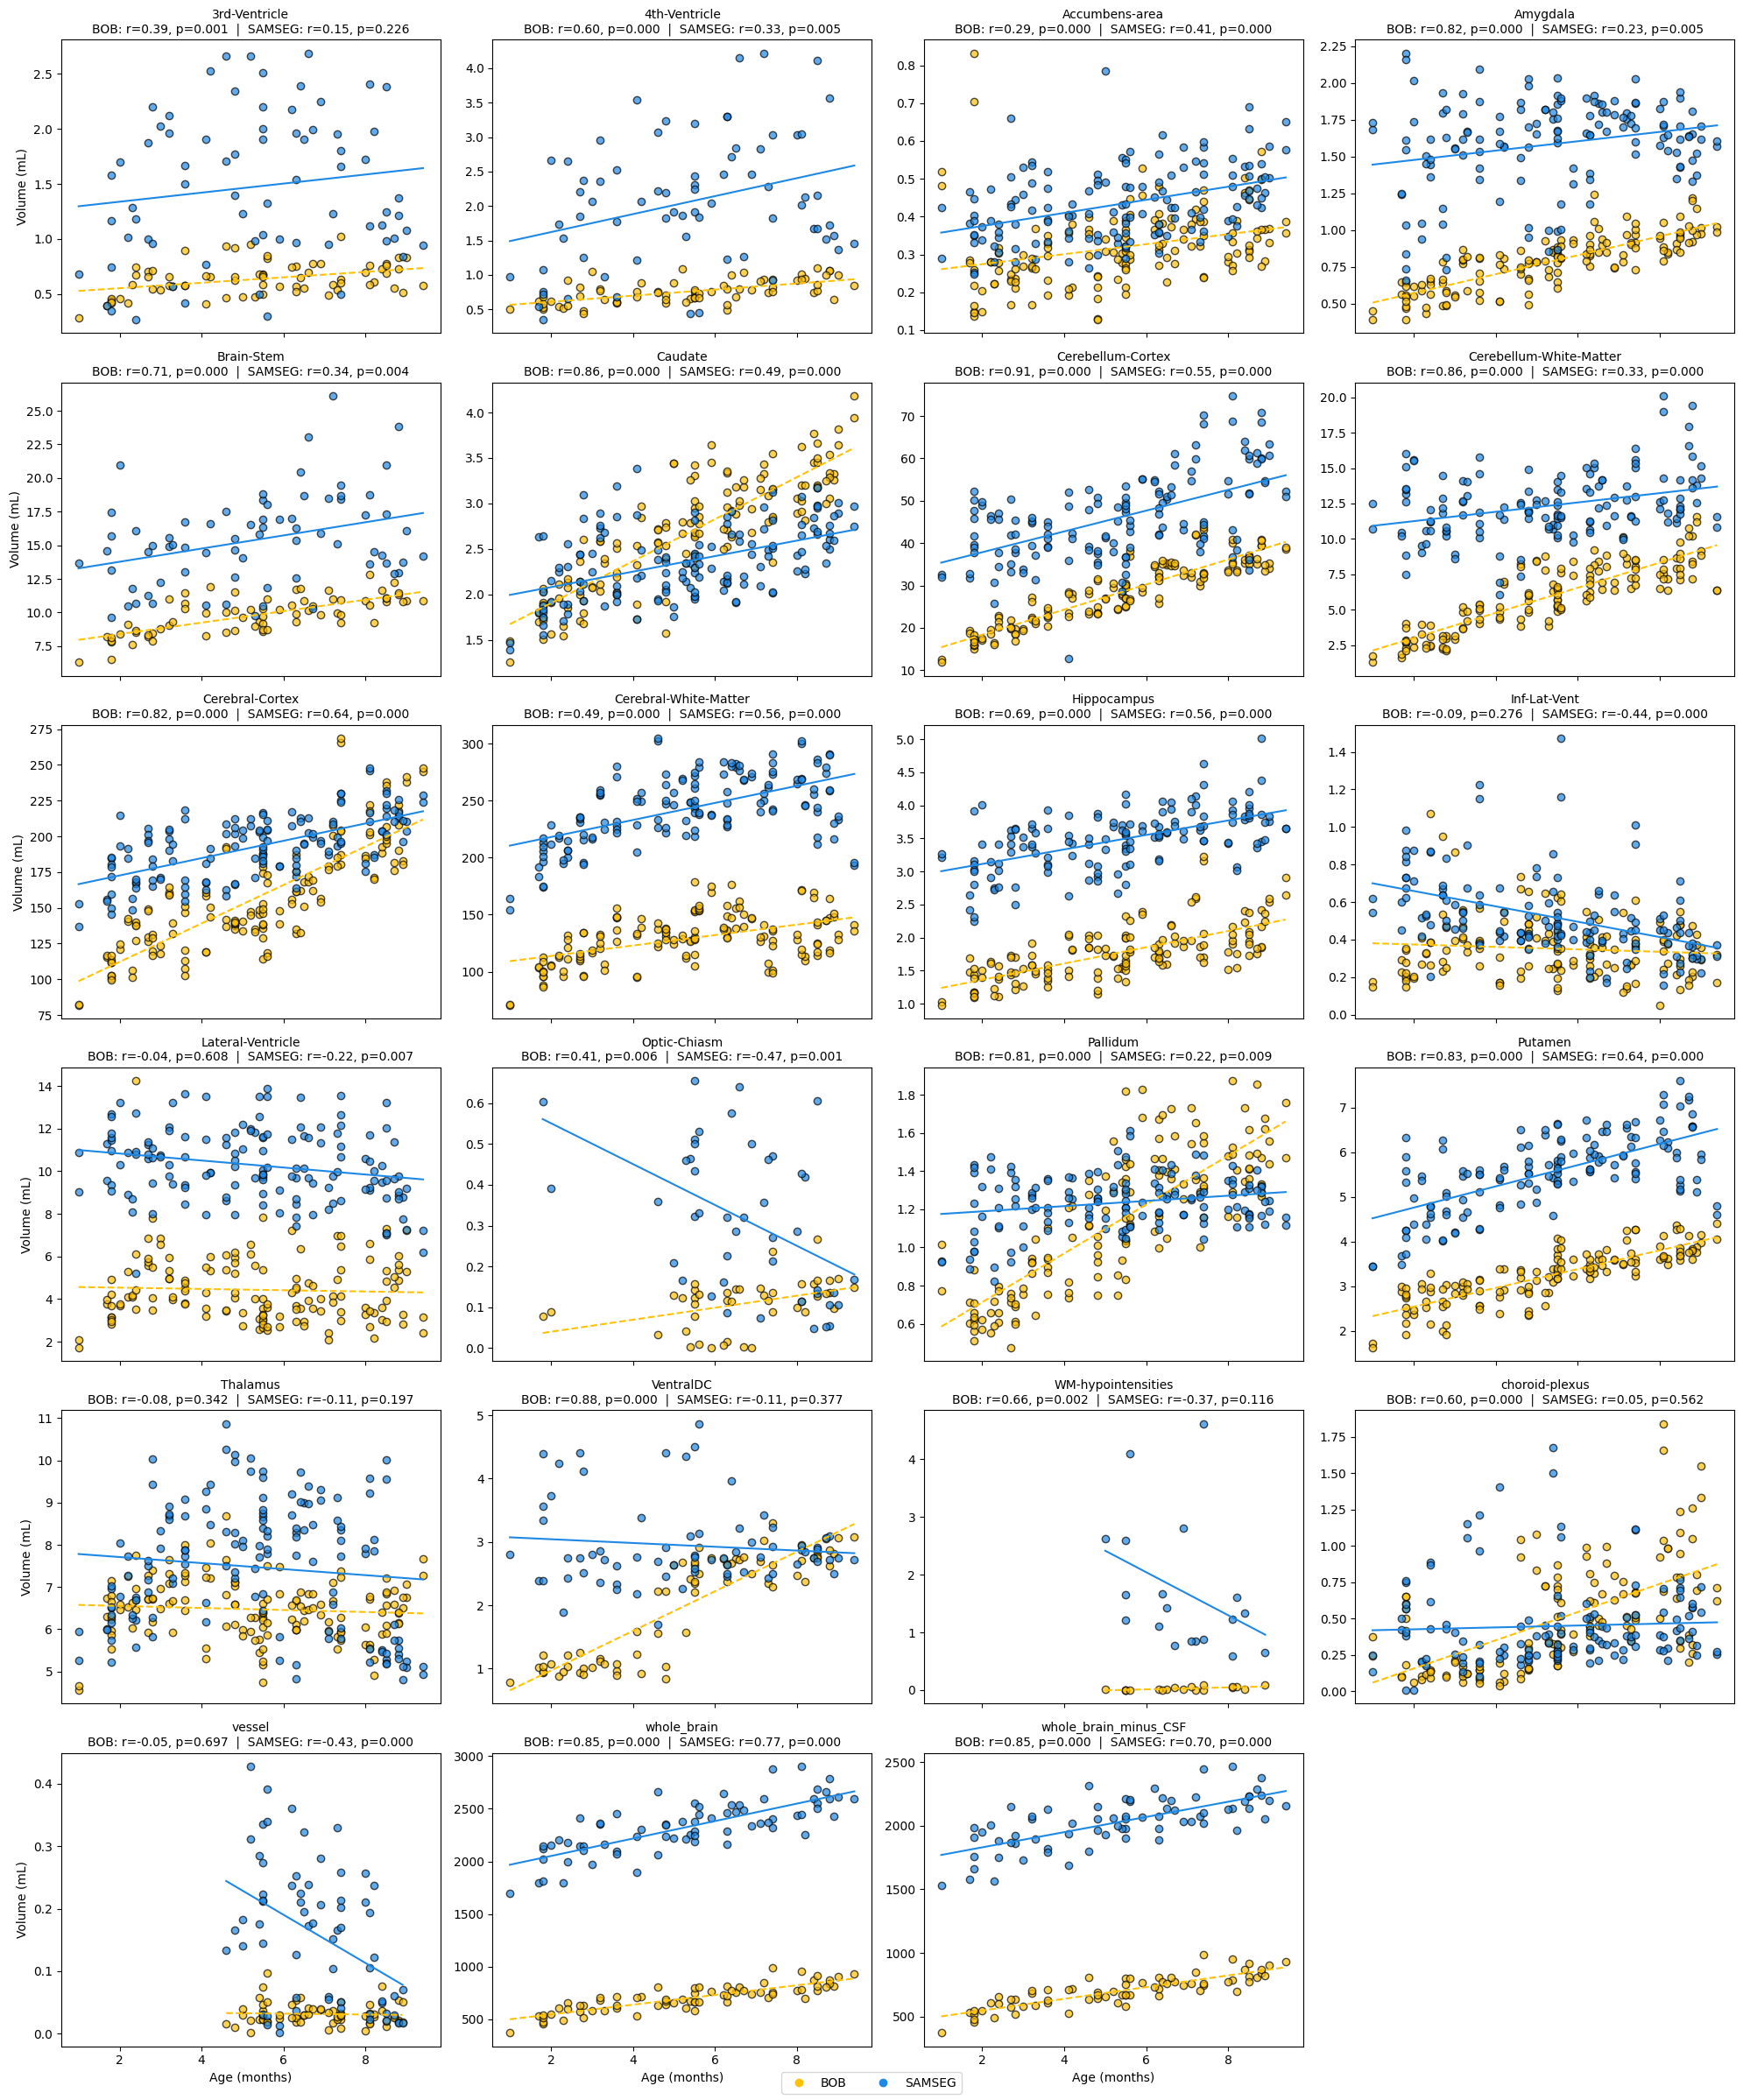

In [13]:
n = len(base_list)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 5, nrows * 4),
    sharex=True
)
axes = axes.flatten()

for idx, base in enumerate(base_list):
    ax = axes[idx]
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == base]
    ages = sub['age'].values
    vols_BOB      = sub['volume_BOB'].values
    vols_Samseg = sub['volume_Samseg'].values

    ax.scatter(ages, vols_BOB, label='BOB', color=colors_seg[0], edgecolor='k', alpha=0.7)
    ax.scatter(ages, vols_Samseg, label='SAMSEG', color=colors_seg[1], edgecolor='k', alpha=0.7)

    if len(ages) > 1:
        slope_bob, intercept_bob = np.polyfit(ages, vols_BOB, 1)
        x_line = np.linspace(ages.min(), ages.max(), 100)
        y_line_bob = slope_bob * x_line + intercept_bob
        ax.plot(x_line, y_line_bob, color=colors_seg[0], linestyle='--')

    if len(ages) > 1:
        slope_ss, intercept_ss = np.polyfit(ages, vols_Samseg, 1)
        y_line_ss = slope_ss * x_line + intercept_ss
        ax.plot(x_line, y_line_ss, color=colors_seg[1], linestyle='-')

    if len(ages) > 1:
        r_bob, p_bob = pearsonr(ages, vols_BOB)
        r_ss,  p_ss  = pearsonr(ages, vols_Samseg)
    else:
        r_bob = p_bob = r_ss = p_ss = np.nan

    ax.set_title(
        f"{base}\nBOB: r={r_bob:.2f}, p={p_bob:.3f}  |  SAMSEG: r={r_ss:.2f}, p={p_ss:.3f}",
        fontsize=10
    )

    if idx // ncols == nrows - 1:
        ax.set_xlabel("Age (months)")
    if idx % ncols == 0:
        ax.set_ylabel("Volume (mL)")

for j in range(n, len(axes)):
    axes[j].axis('off')

handles = [
    plt.Line2D([], [], marker='o', linestyle='None',
               color=colors_seg[0], label='BOB'),
    plt.Line2D([], [], marker='o', linestyle='None',
               color=colors_seg[1], label='SAMSEG')
]
fig.legend(handles=handles, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

### Correlation with quality metrics

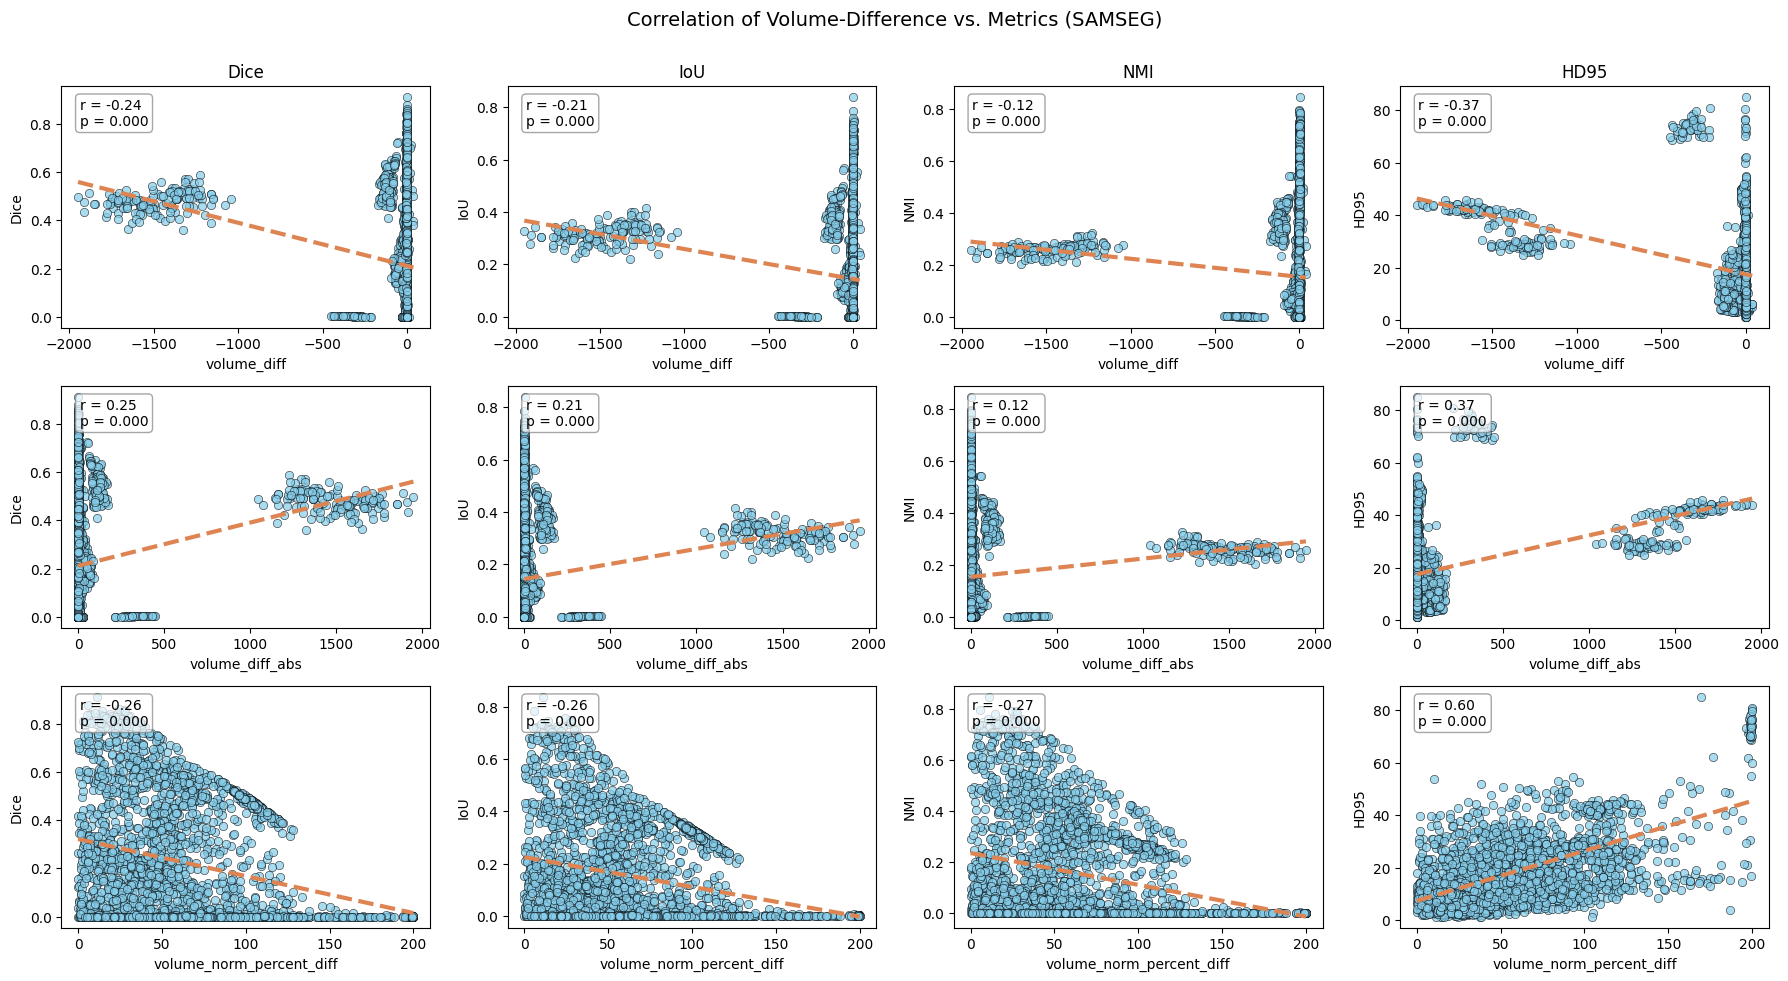

In [14]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_cols  = ["volume_diff", "volume_diff_abs", "volume_norm_percent_diff"]

nrows = len(x_cols)
ncols = len(metrics)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.5, nrows * 3.5),
    sharex=False
)
axes = np.array(axes)

for i, x_col in enumerate(x_cols):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        sub = df_fd_volume_metrics.dropna(subset=[x_col, metric])
        x = sub[x_col].values
        y = sub[metric].values
        sns.scatterplot(x=x, y=y, ax=ax, color='skyblue', edgecolor='k', alpha=0.7)
        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="#dd8452", linestyle="--", lw=3)
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.7)
        )
        if i == 0:
            ax.set_title(metric, fontsize=12)
        ax.set_ylabel(metric, fontsize=10)
        ax.set_xlabel(x_col, fontsize=10)

fig.suptitle("Correlation of Volume‐Difference vs. Metrics (SAMSEG)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.975])
plt.show()

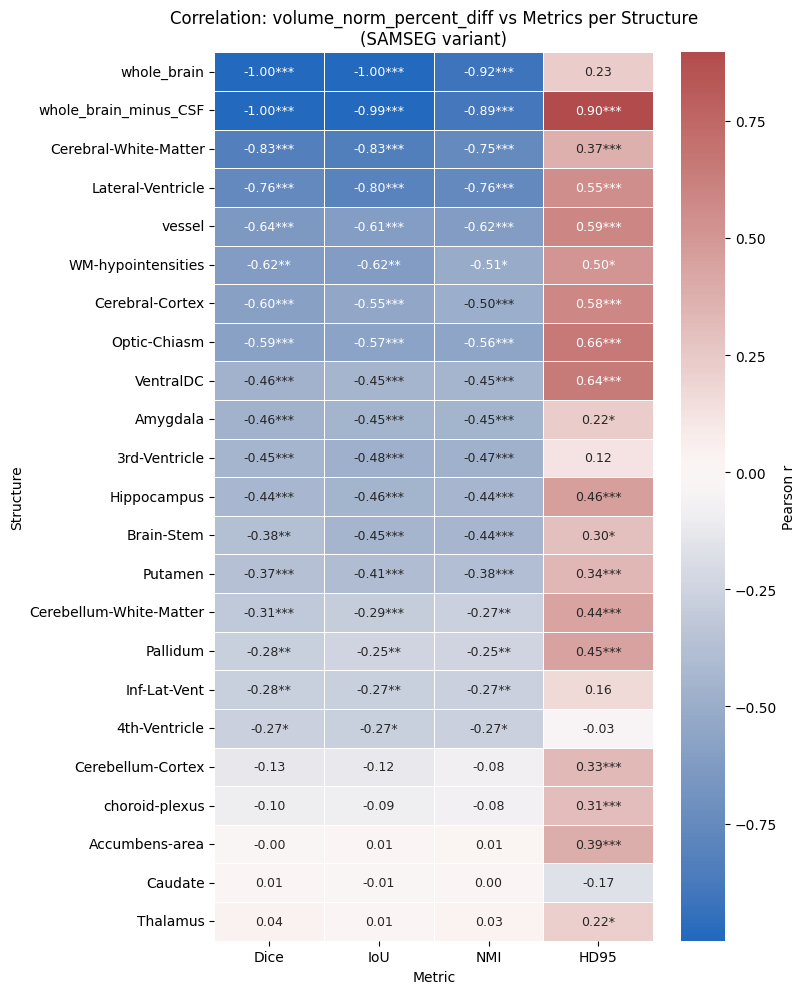

In [15]:
corr_vol, pvals_vol = plot_structure_metric_correlations(
    df_fd_volume_metrics,
    selected_name=selected_name,
    x_col="volume_norm_percent_diff",
    use_fdr=True,
    alpha=0.05
)

## Fractal dimension

### BOB vs. SAMSEG

In [16]:
stats_list = []

for label in base_list:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == label]
    if sub.empty:
        continue
    bob = sub['fd_BOB']
    sam = sub['fd_Samseg']
    diff = bob - sam
    mean_diff = diff.mean()
    sd_diff   = diff.std(ddof=1)
    t_stat, p_val = ttest_rel(bob, sam)
    d_val = ut.cohen_d_paired(bob, sam)
    stats_list.append({
        'name': label,
        'FD (BOB)': f"{bob.mean():.2f} ± {bob.std(ddof=1):.2f}",
        'FD (SAMSEG)': f"{sam.mean():.2f} ± {sam.std(ddof=1):.2f}",
        'FD (diff)': f"{mean_diff:.2f} ± {sd_diff:.2f}",
        'n': len(diff),
        'p-val': f"{p_val:.3f}",
        'd': f"{d_val:.2f}"
    })

df_stats = pd.DataFrame(stats_list)
df_stats

,name,FD (BOB),FD (SAMSEG),FD (diff),n,p-val,d
0,3rd-Ventricle,1.74 ± 0.11,1.85 ± 0.16,-0.11 ± 0.18,71,0.000,-0.62
1,4th-Ventricle,1.67 ± 0.15,1.81 ± 0.15,-0.14 ± 0.19,71,0.000,-0.75
2,Accumbens-area,1.61 ± 0.08,1.63 ± 0.15,-0.02 ± 0.16,142,0.228,-0.10
3,Amygdala,1.84 ± 0.12,1.95 ± 0.08,-0.11 ± 0.13,142,0.000,-0.81
4,Brain-Stem,2.29 ± 0.02,2.30 ± 0.05,-0.02 ± 0.05,71,0.003,-0.37
5,Caudate,2.01 ± 0.04,1.91 ± 0.05,0.10 ± 0.05,142,0.000,2.02
6,Cerebellum-Cortex,2.44 ± 0.04,2.48 ± 0.04,-0.05 ± 0.04,142,0.000,-1.03
7,Cerebellum-White-Matter,2.08 ± 0.06,2.22 ± 0.05,-0.14 ± 0.07,142,0.000,-2.08
8,Cerebral-Cortex,2.47 ± 0.05,2.40 ± 0.02,0.07 ± 0.05,142,0.000,1.39
9,Cerebral-White-Matter,2.44 ± 0.04,2.57 ± 0.02,-0.13 ± 0.04,142,0.000,-3.26


/tmp/ipykernel_1047725/1547264077.py:37: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.2, wspace=0.2)


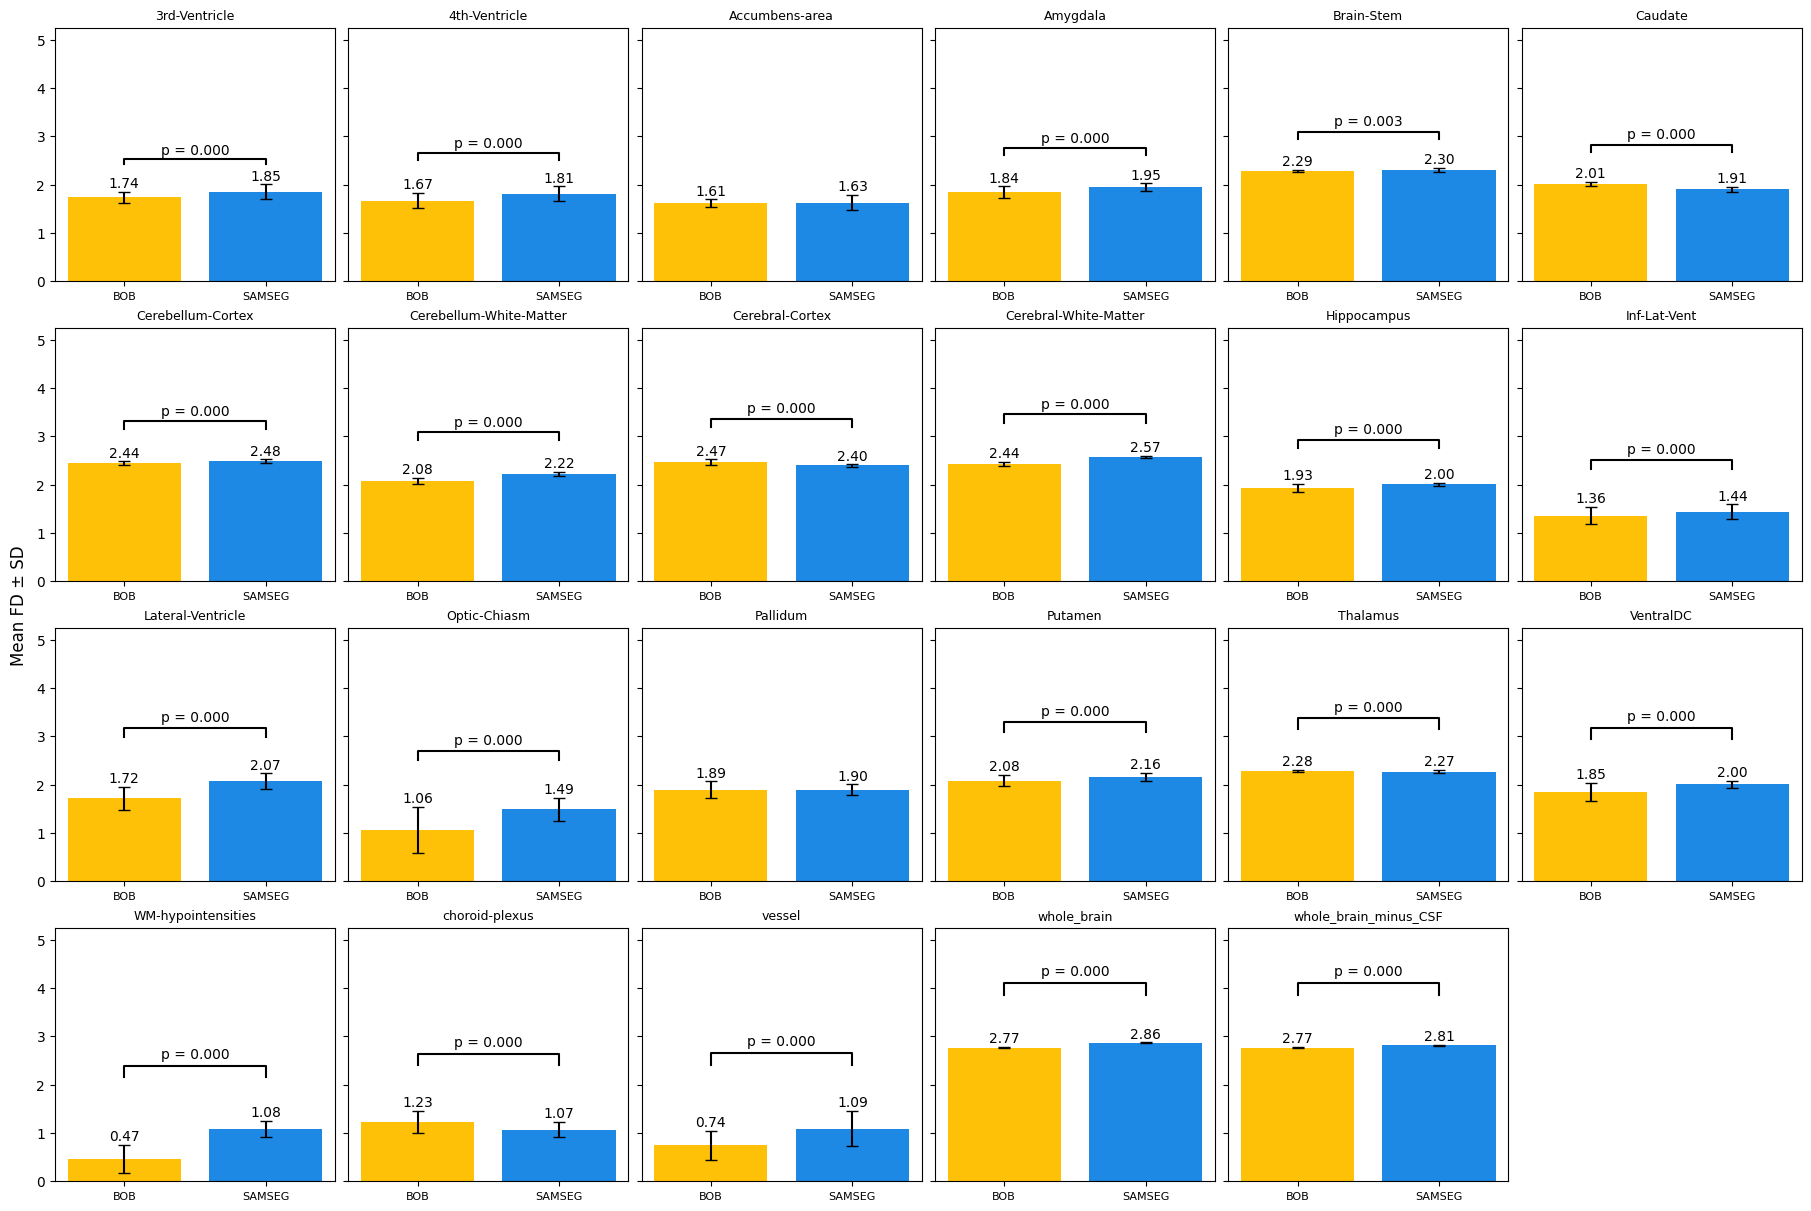

In [17]:
agg = df_fd_volume_metrics.groupby(selected_name)[['fd_BOB', 'fd_Samseg']].agg(['mean', 'std'])

n_pairs = len(base_list)
ncols = 6
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3, nrows*3), sharey=True, constrained_layout=True)
axes = axes.flatten()

for ax, label in zip(axes, base_list):
    if label not in agg.index:
        ax.axis('off')
        continue
    means = agg.loc[label][('fd_BOB', 'mean')], agg.loc[label][('fd_Samseg', 'mean')]
    stds  = agg.loc[label][('fd_BOB', 'std')],  agg.loc[label][('fd_Samseg', 'std')]

    x = np.arange(2)
    ax.bar(x, means, yerr=stds, capsize=4, color=colors_seg)
    ax.set_xticks(x)
    ax.set_xticklabels(['BOB', 'SAMSEG'], fontsize=8)
    ax.set_title(label, fontsize=9)

    for xi, m, sd in zip(x, means, stds):
        ax.text(xi, m + (sd if not np.isnan(sd) else 0) + 0.03, f"{m:.2f}", ha='center', va='bottom', fontsize=10)

    p = float(df_stats[df_stats['name'] == label]['p-val'].iloc[0]) if label in set(df_stats['name']) else np.nan
    if not np.isnan(p) and p < 0.05:
        ut.barplot_annotate_brackets(0, 1,
            f'p = {p:.3f}', x, means, yerr=stds, dh=0.2,  ax=ax
        )
    ax.set_ylim([min(ax.get_ylim()), max(ax.get_ylim()) * 1.03])

for ax in axes[n_pairs:]:
    ax.axis('off')

fig.supylabel("Mean FD ± SD")
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

In [18]:
# Bonferroni correction for FD paired tests
n_tests = len(df_stats)
alpha_corr = 0.05 / n_tests if n_tests else np.nan

df_stats['p_nominal'] = df_stats['p-val'].astype(float)
df_stats['sign_corr'] = df_stats['p_nominal'] < alpha_corr if not np.isnan(alpha_corr) else False

print(f"Bonferroni α = {alpha_corr:.4f}" if not np.isnan(alpha_corr) else "No tests")
df_stats.loc[df_stats['sign_corr'], ['name', 'FD (BOB)', 'FD (SAMSEG)', 'FD (diff)','n', 'p-val', 'd']]

Bonferroni α = 0.0022


,name,FD (BOB),FD (SAMSEG),FD (diff),n,p-val,d
0,3rd-Ventricle,1.74 ± 0.11,1.85 ± 0.16,-0.11 ± 0.18,71,0.000,-0.62
1,4th-Ventricle,1.67 ± 0.15,1.81 ± 0.15,-0.14 ± 0.19,71,0.000,-0.75
3,Amygdala,1.84 ± 0.12,1.95 ± 0.08,-0.11 ± 0.13,142,0.000,-0.81
5,Caudate,2.01 ± 0.04,1.91 ± 0.05,0.10 ± 0.05,142,0.000,2.02
6,Cerebellum-Cortex,2.44 ± 0.04,2.48 ± 0.04,-0.05 ± 0.04,142,0.000,-1.03
7,Cerebellum-White-Matter,2.08 ± 0.06,2.22 ± 0.05,-0.14 ± 0.07,142,0.000,-2.08
8,Cerebral-Cortex,2.47 ± 0.05,2.40 ± 0.02,0.07 ± 0.05,142,0.000,1.39
9,Cerebral-White-Matter,2.44 ± 0.04,2.57 ± 0.02,-0.13 ± 0.04,142,0.000,-3.26
10,Hippocampus,1.93 ± 0.08,2.00 ± 0.04,-0.07 ± 0.08,142,0.000,-0.92
11,Inf-Lat-Vent,1.36 ± 0.18,1.44 ± 0.15,-0.08 ± 0.23,142,0.000,-0.37


### BOB/SAMSEG over age

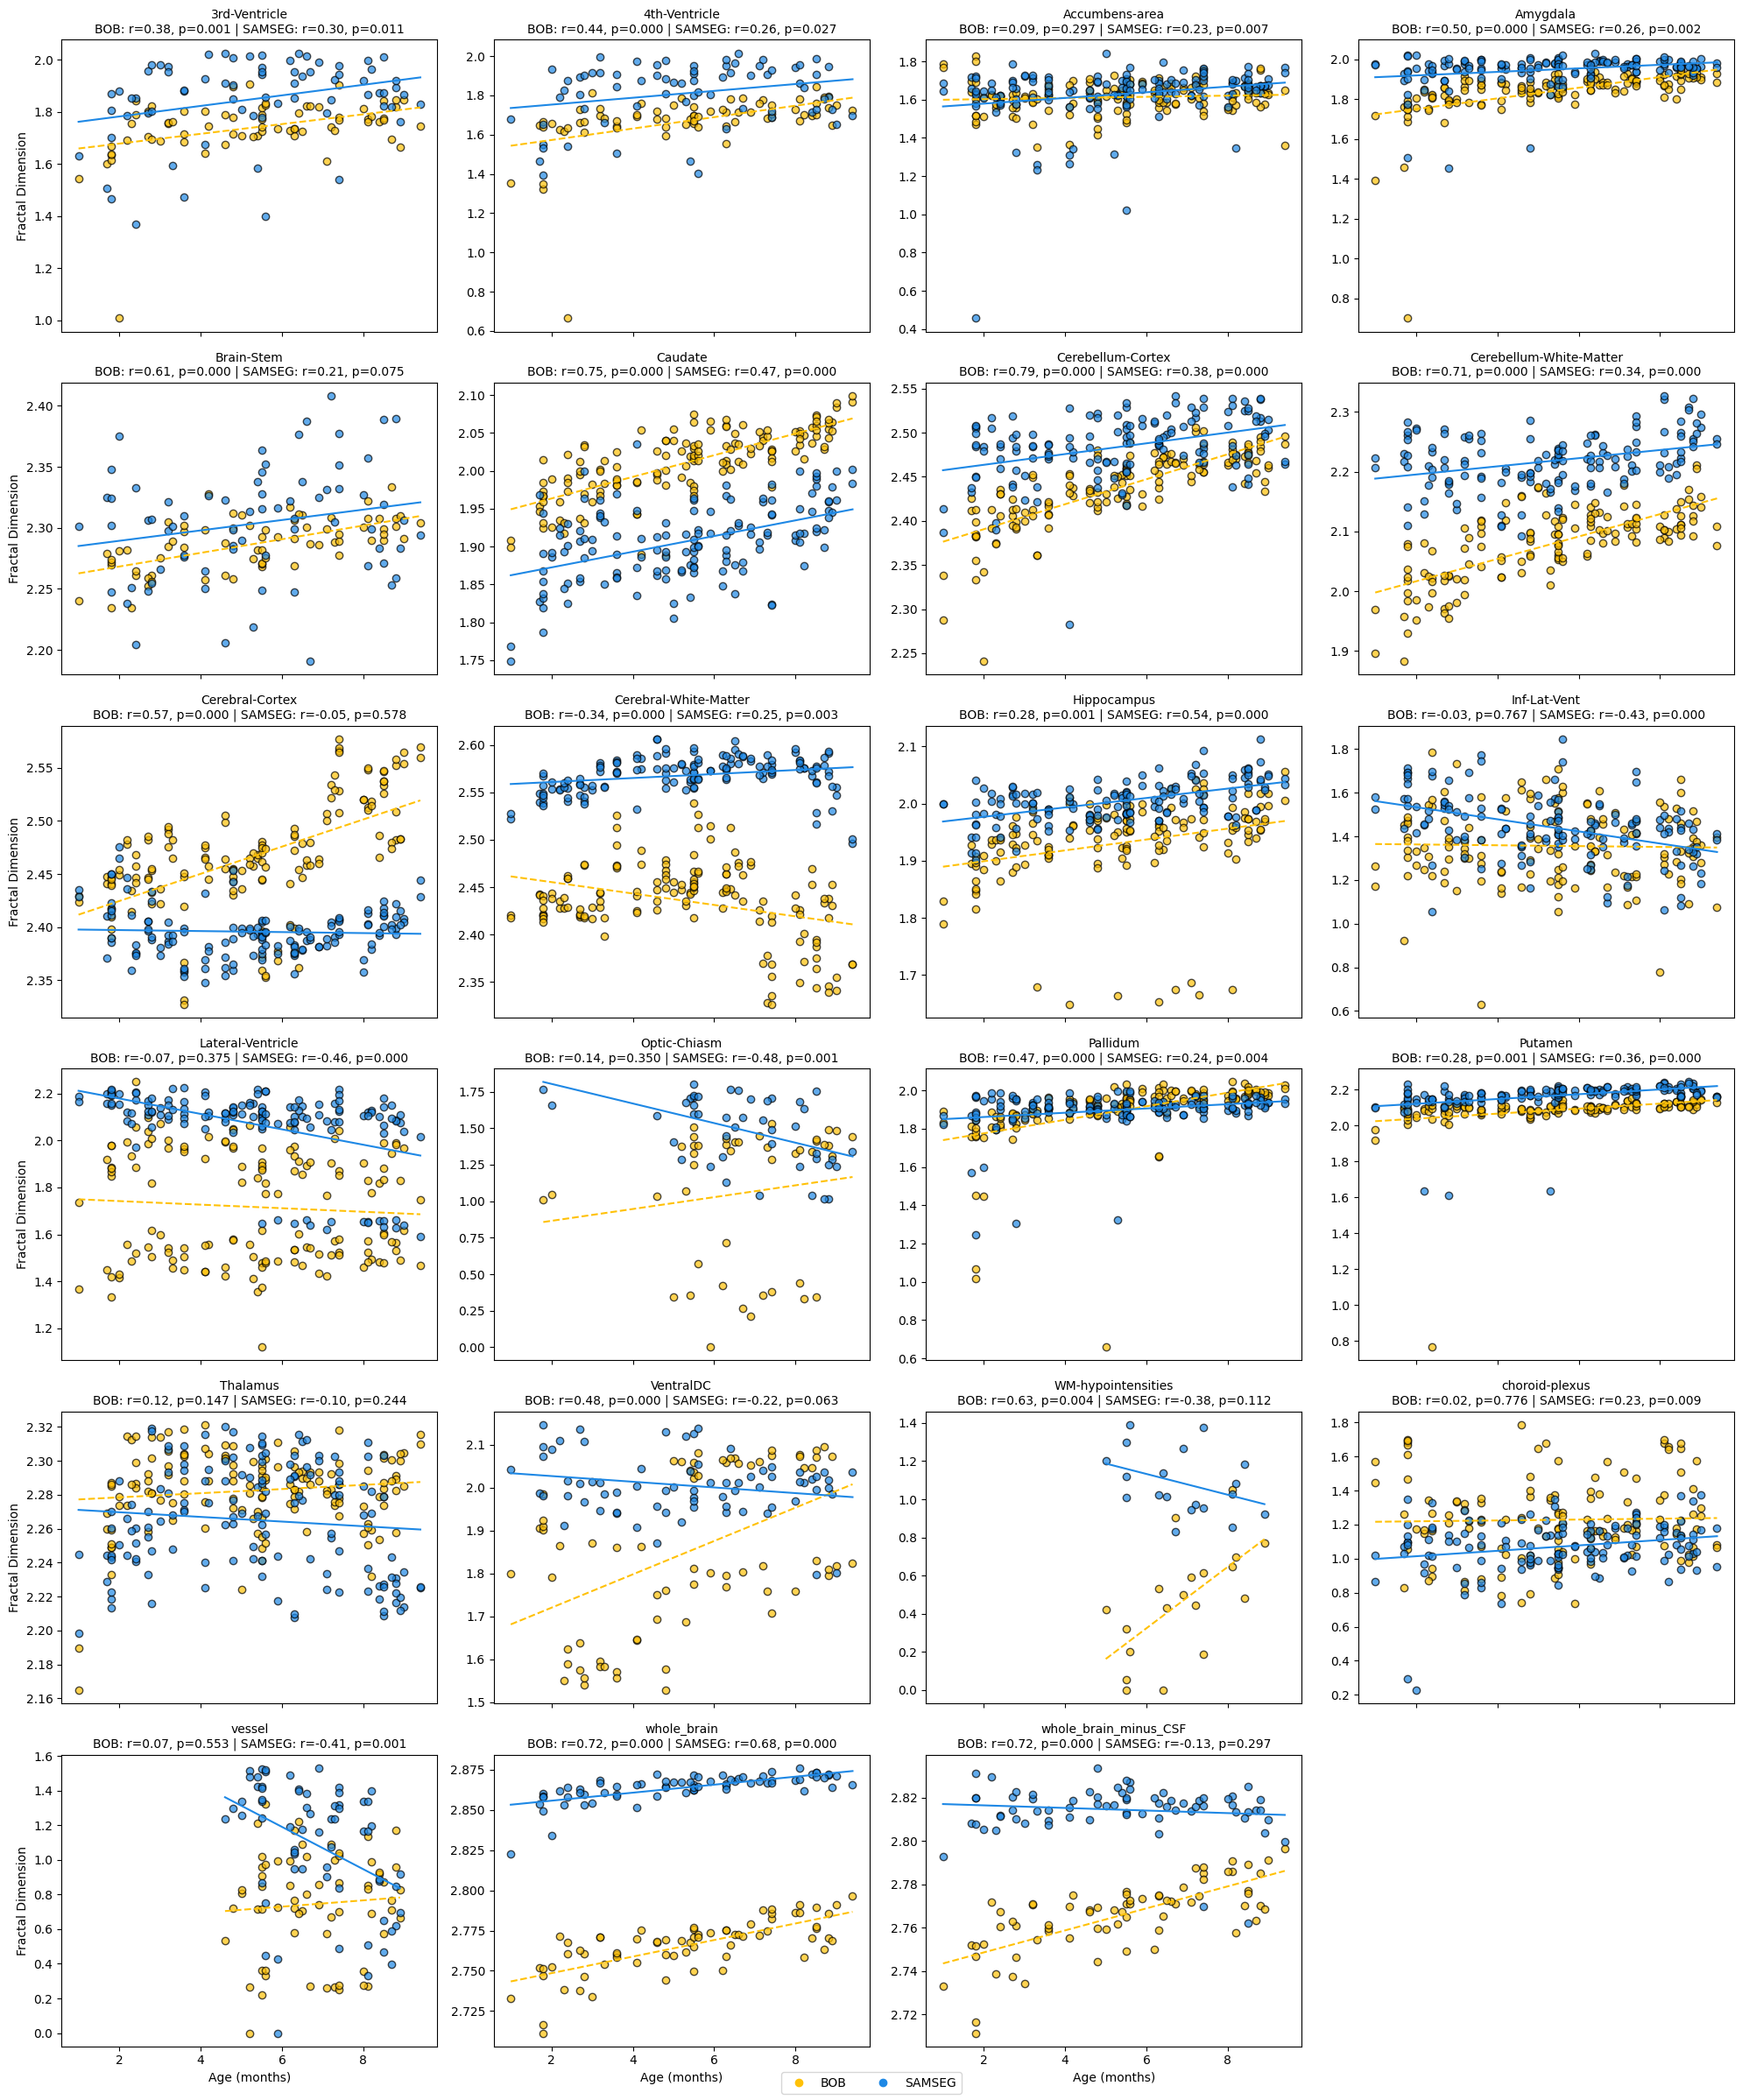

In [19]:
n = len(base_list)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5, nrows * 4),
                         sharex=True)
axes = axes.flatten()

for idx, base in enumerate(base_list):
    ax = axes[idx]
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == base]
    ages = sub['age'].values
    fds_BOB = sub['fd_BOB'].values
    fds_sam = sub['fd_Samseg'].values

    ax.scatter(ages, fds_BOB, label='BOB', color=colors_seg[0], edgecolor='k', alpha=0.7)
    ax.scatter(ages, fds_sam, label='SAMSEG', color=colors_seg[1], edgecolor='k', alpha=0.7)

    if len(ages) > 1:
        slope_bob, intercept_bob = np.polyfit(ages, fds_BOB, 1)
        x_line = np.linspace(ages.min(), ages.max(), 100)
        y_line_bob = slope_bob * x_line + intercept_bob
        ax.plot(x_line, y_line_bob, color=colors_seg[0], linestyle='--')

    if len(ages) > 1:
        slope_ss, intercept_ss = np.polyfit(ages, fds_sam, 1)
        y_line_ss = slope_ss * x_line + intercept_ss
        ax.plot(x_line, y_line_ss, color=colors_seg[1], linestyle='-')

    if len(ages) > 1:
        r_bob, p_bob = pearsonr(ages, fds_BOB)
        r_ss, p_ss = pearsonr(ages, fds_sam)
    else:
        r_bob = p_bob = r_ss = p_ss = np.nan

    ax.set_title(f"{base}\nBOB: r={r_bob:.2f}, p={p_bob:.3f} | SAMSEG: r={r_ss:.2f}, p={p_ss:.3f}", fontsize=10)

    if idx // ncols == nrows - 1:
        ax.set_xlabel("Age (months)")
    if idx % ncols == 0:
        ax.set_ylabel("Fractal Dimension")

for j in range(n, len(axes)):
    axes[j].axis('off')

handles = [plt.Line2D([], [], marker='o', linestyle='None', color=colors_seg[0], label='BOB'),
           plt.Line2D([], [], marker='o', linestyle='None', color=colors_seg[1], label='SAMSEG')]
fig.legend(handles=handles, loc='lower center', ncol=2)

plt.tight_layout()
plt.show()

### Correlation with quality metrics

In [20]:
# Ensure FD diff columns exist for correlation plots
if 'fd_diff' not in df_fd_volume_metrics.columns:
    df_fd_volume_metrics['fd_diff'] = df_fd_volume_metrics['fd_BOB'] - df_fd_volume_metrics['fd_Samseg']
if 'fd_diff_abs' not in df_fd_volume_metrics.columns:
    df_fd_volume_metrics['fd_diff_abs'] = df_fd_volume_metrics['fd_diff'].abs()

df_fd_volume_metrics.columns

Index(['participant_id', 'session_id', 'name', 'fd_BOB', 'age', 'sex',
       'fd_Samseg', 'volume_BOB', 'volume_Samseg', 'volume_diff',
       'volume_diff_abs', 'volume_norm_percent_diff', 'volume_ratio', 'Dice',
       'HD95', 'Hausdorff', 'IoU', 'MI', 'NMI', 'fd_diff', 'fd_diff_abs',
       'base_name', 'side'],
      dtype='object')

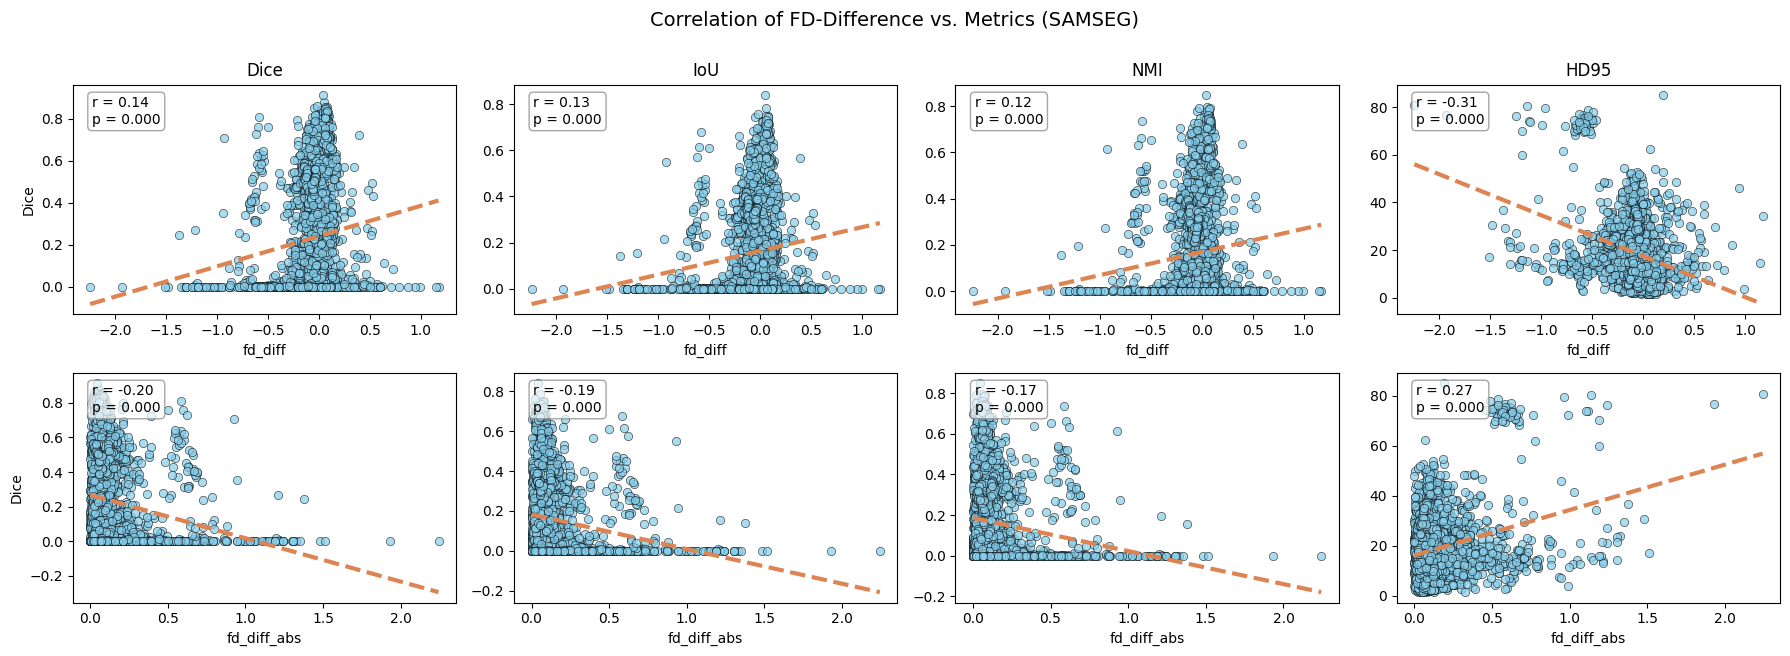

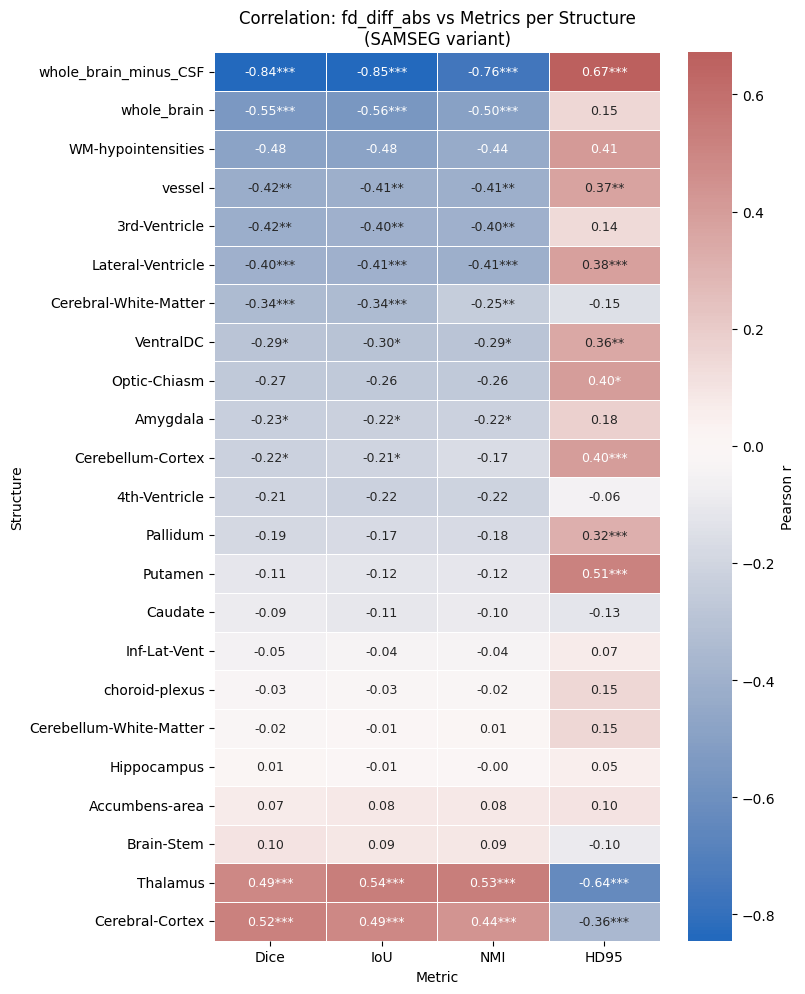

In [21]:
metrics = ["Dice", "IoU", "NMI", "HD95"]
x_cols  = ["fd_diff", "fd_diff_abs"]

nrows = len(x_cols)
ncols = len(metrics)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.5, nrows * 3.5),
    sharex=False
)
axes = np.array(axes)

for i, x_col in enumerate(x_cols):
    for j, metric in enumerate(metrics):
        ax = axes[i, j]
        sub = df_fd_volume_metrics.dropna(subset=[x_col, metric])
        x = sub[x_col].values
        y = sub[metric].values
        sns.scatterplot(x=x, y=y, ax=ax, color='skyblue', edgecolor='k', alpha=0.7)
        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            x_line = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color="#dd8452", linestyle="--", lw=3)
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan
        ax.text(
            0.05, 0.95,
            f"r = {r:.2f}\np = {p:.3f}",
            transform=ax.transAxes,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.7)
        )
        if i == 0:
            ax.set_title(metric, fontsize=12)
        if j == 0:
            ax.set_ylabel(metric, fontsize=10)
        else:
            ax.set_ylabel("")
        ax.set_xlabel(x_col, fontsize=10)

fig.suptitle("Correlation of FD‐Difference vs. Metrics (SAMSEG)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.05, 1, 0.975])
plt.show()

corr_fd, pvals_fd = plot_structure_metric_correlations(
    df_fd_volume_metrics,
    selected_name=selected_name,
    x_col="fd_diff_abs",
    use_fdr=True,
    alpha=0.05
)

## Volume diff and FD diff correlation

/tmp/ipykernel_1047725/4138883411.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


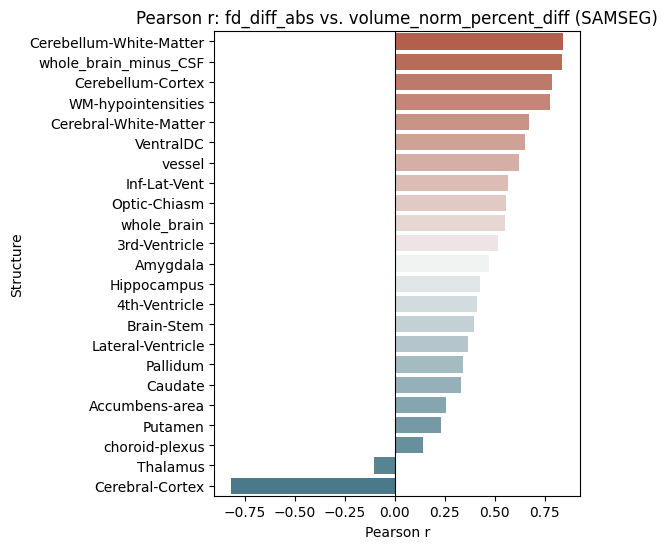

In [22]:
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

structures = [name for name in df_fd_volume_metrics[selected_name].unique() if name != 'CSF']

corr_list = []
for struct in structures:
    sub = df_fd_volume_metrics[df_fd_volume_metrics[selected_name] == struct]
    sub = sub.dropna(subset=["fd_diff_abs", "volume_norm_percent_diff"])
    if len(sub) > 1:
        r, p = pearsonr(sub["volume_norm_percent_diff"], sub["fd_diff_abs"])
    else:
        r, p = np.nan, np.nan
    corr_list.append({"name": struct, "r": r, "p": p})

corr_df = pd.DataFrame(corr_list).set_index("name").sort_values("r", ascending=False)
palette = sns.diverging_palette(20, 220, n=len(corr_df), as_cmap=False)

plt.figure(figsize=(6, len(corr_df) * 0.2 + 1))
sns.barplot(
    x="r",
    y=corr_df.index,
    data=corr_df.reset_index(),
    palette=palette,
)
plt.axvline(0, color="k", linewidth=0.8)
plt.title("Pearson r: fd_diff_abs vs. volume_norm_percent_diff (SAMSEG)")
plt.xlabel("Pearson r")
plt.ylabel("Structure")
plt.tight_layout()
plt.show()